# Judge + Ablation Analysis

Loads the evaluation artifacts from `reports/`, computes concise statistics, bootstraps a confidence interval for the judge win-rate, creates plots (win/tie breakdown and ROUGE comparison), and exports curated example CSVs for qualitative review.

Files used: `reports/judge_winrate.json`, `reports/ablation_summary.json`, `reports/ablation_long_summary.json`, `reports/safety_summary.json`, and `reports/judge_cases.1000.jsonl`.


- Load report JSONs and the judge JSONL.
- Compute raw counts and bootstrap 95% CI for win-rate on decisive comparisons.
- Plot wins/ties and ROUGE-L comparisons (balanced + long).
- Export curated CSV samples: SFT-wins, DPO-wins, ties.
- Save figures and CSVs to `reports/analysis_outputs/`.

In [7]:
import re, json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

%matplotlib inline

ROOT = Path('/home/linux/Source/Dev/AlignTune')
REPORTS = ROOT / 'reports'
JUDGE_JSON = REPORTS / 'judge_winrate.json'
ABLATION_JSON = REPORTS / 'ablation_summary.json'
ABLATION_LONG_JSON = REPORTS / 'ablation_long_summary.json'
SAFETY_JSON = REPORTS / 'safety_summary.json'
JUDGE_CASES = REPORTS / 'judge_cases.1000.jsonl'
OUT_DIR = REPORTS / 'analysis_outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('Reports path:', REPORTS)

ASSIST_USER_PREFIX = re.compile(r'(?is)\bassistant\s*\.?\s*user\s*[:.]?\s*')

def _collapse_ws(x: str) -> str:
    x = re.sub(r'[ \t]+', ' ', x)
    x = re.sub(r'\n{3,}', '\n\n', x)
    return x.strip()

def strip_preamble_only(text: str) -> str:
    if not isinstance(text, str) or not text:
        return text
    s = text.replace('\r\n', '\n').replace('\r', '\n').lstrip('\ufeff')
    m = ASSIST_USER_PREFIX.search(s[:300])
    if m:
        s = s[m.end():]
    else:
        s = re.sub(r'(?im)^\s*(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec)[a-z]*\s+\d{4}\s*\n', '', s, count=1)
        s = re.sub(r'(?im)^\s*\d{4}-\d{2}-\d{2}\s*\n', '', s, count=1)
        s = re.sub(r'(?im)^(?:Cutting\s+Knowledge\s+Date|Knowledge\s+Cutoff|Today\s+Date|Current\s+date)\s*:\s*[^\n]*\n?', '', s)
        s = re.sub(r'(?im)^\s*(?:system|user)\s*[:.]?\s*', '', s, count=1)
        s = re.sub(r'(?is)^\s*You\s+are\s+(?:a\s+)?helpful,\s*concise\s+assistant\.?\s*', '', s, count=1)
    return _collapse_ws(s)

ASSIST_ANY = re.compile(r'(?is)assistant\s*[:.]?\s*')

def extract_reply(text: str) -> str:
    s = strip_preamble_only(text)
    m = ASSIST_ANY.search(s)
    if m:
        s = s[m.end():]
        s = re.sub(r'^[\s:.\-–—>]*', '', s)
    else:
        s = re.sub(r'(?im)^\s*(?:user|Person|Persona|Character|Topic|Role|Prompt|Question)\s*[:.]?\s*', '', s, count=1)
    return _collapse_ws(s)

Reports path: /home/linux/Source/Dev/AlignTune/reports


In [8]:
def load_json(p: Path):
    if not p.exists():
        print(f'Missing: {p}')
        return None
    try:
        return json.loads(p.read_text(encoding='utf-8'))
    except Exception as ex:
        print('Error loading', p, ex)
        return None

judge = load_json(JUDGE_JSON)
ablation = load_json(ABLATION_JSON)
ablation_long = load_json(ABLATION_LONG_JSON)
safety = load_json(SAFETY_JSON)

In [9]:
if judge is None:
    print('judge_winrate.json missing; cannot summarize')
else:
    wins_a = int(judge.get('wins_a', 0))
    wins_b = int(judge.get('wins_b', 0))
    ties = int(judge.get('ties', 0))
    decisive = wins_a + wins_b
    print('Judge summary (reported):')
    print('  model_a:', judge.get('model_a'))
    print('  model_b:', judge.get('model_b'))
    print('  prompts requested n:', judge.get('n'))
    print(f'  wins_a={wins_a}, wins_b={wins_b}, ties={ties}, decisive={decisive}')
    if decisive>0:
        reported_wr_a = judge.get('win_rate_a')
        print('  reported win_rate_a:', reported_wr_a)

Judge summary (reported):
  model_a: Llama-3.1-8B-Instruct-lora
  model_b: Llama-3.1-8B-Instruct-lora-dpo
  prompts requested n: 1000
  wins_a=700, wins_b=742, ties=303, decisive=1442
  reported win_rate_a: 0.4854368932038835


In [10]:
def bootstrap_winrate(wins_a, wins_b, n_iter=2000, seed=42):
    n = wins_a + wins_b
    if n == 0:
        return None
    rng = np.random.default_rng(seed)
    data = np.concatenate([np.ones(wins_a, dtype=int), np.zeros(wins_b, dtype=int)])
    props = rng.choice(data, size=(n_iter, n), replace=True).mean(axis=1)
    return float(props.mean()), float(np.percentile(props, 2.5)), float(np.percentile(props, 97.5))

if judge is not None and (wins_a + wins_b) > 0:
    mean_boot, low_boot, high_boot = bootstrap_winrate(wins_a, wins_b, n_iter=2000)
    print('Bootstrap (2000 iters) win_rate_a on decisive comparisons:')
    print(f'  mean={mean_boot:.4f}, 95% CI=[{low_boot:.4f}, {high_boot:.4f}]')
else:
    print('Skipping bootstrap (no decisive comparisons)')

Bootstrap (2000 iters) win_rate_a on decisive comparisons:
  mean=0.4852, 95% CI=[0.4591, 0.5097]


Saved plot to /home/linux/Source/Dev/AlignTune/reports/analysis_outputs/win_tie_and_rouge.png


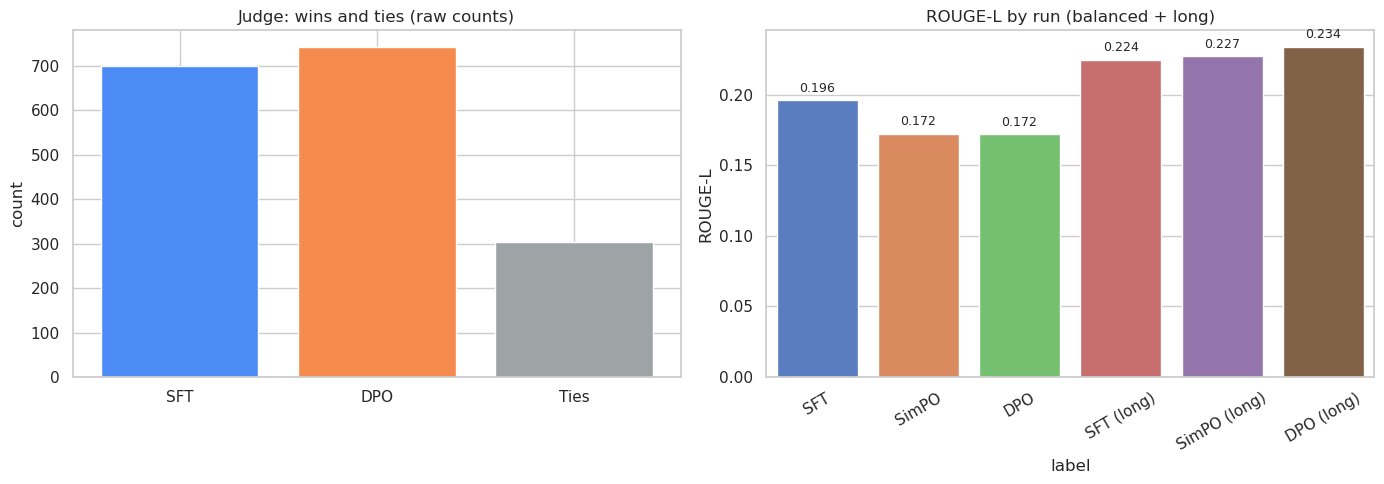

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if judge is not None:
    axes[0].bar(['SFT', 'DPO', 'Ties'], [wins_a, wins_b, ties], color=['#4c8bf5', '#f58b4c', '#9ea3a6'])
    axes[0].set_title('Judge: wins and ties (raw counts)')
    axes[0].set_ylabel('count')
else:
    axes[0].text(0.5, 0.5, 'judge data missing', ha='center')

rouge_rows = []
if ablation is not None:
    for r in ablation.get('runs', []):
        rouge_rows.append({'label': r.get('label'), 'rougeL': r.get('rougeL'), 'n': r.get('n')})
if ablation_long is not None:
    for r in ablation_long.get('runs', []):
        rouge_rows.append({'label': r.get('label'), 'rougeL': r.get('rougeL'), 'n': r.get('n')})
if rouge_rows:
    df_r = pd.DataFrame(rouge_rows)
    order = [r['label'] for r in rouge_rows]
    df_r['label'] = pd.Categorical(df_r['label'], categories=order, ordered=True)
    sns.barplot(
        x='label', y='rougeL', hue='label', data=df_r,
        ax=axes[1], palette='muted', dodge=False, legend=False
    )
    axes[1].set_title('ROUGE-L by run (balanced + long)')
    axes[1].set_ylabel('ROUGE-L')
    axes[1].tick_params(axis='x', rotation=30)
    for p in axes[1].patches:
        y = p.get_height()
        axes[1].text(p.get_x() + p.get_width()/2, y + 0.004, f'{y:.3f}',
                     ha='center', va='bottom', fontsize=9)
else:
    axes[1].text(0.5, 0.5, 'ablation data missing', ha='center')

plt.tight_layout()
out_plot = OUT_DIR / 'win_tie_and_rouge.png'
fig.savefig(out_plot, bbox_inches='tight', dpi=160)
print('Saved plot to', out_plot)
plt.show()

In [12]:
cases = []
if JUDGE_CASES.exists():
    with JUDGE_CASES.open('r', encoding='utf-8') as fh:
        for ln in fh:
            ln = ln.strip()
            if not ln:
                continue
            try:
                obj = json.loads(ln)
            except Exception:
                continue
            cases.append({
                'prompt': obj.get('prompt'),
                'A': obj.get('A'),
                'B': obj.get('B'),
                'judge': obj.get('judge')
            })

    df_cases = pd.DataFrame(cases)

    if 'prompt' in df_cases:
        df_cases['prompt'] = df_cases['prompt'].map(strip_preamble_only)

    for col in ['A', 'B']:
        if col in df_cases:
            df_cases[col] = df_cases[col].map(extract_reply)

    def save_sample(tag, label):
        sub = df_cases[df_cases['judge'] == label]
        if len(sub):
            out_path = (OUT_DIR / f'{tag}_examples.csv').resolve()
            sub.sample(n=min(10, len(sub)), random_state=42)[['prompt','A','B','judge']].to_csv(out_path, index=False)
            print(f'Saved {tag} examples -> {out_path}')

    save_sample('SFT_win', 'A')
    save_sample('DPO_win', 'B')
    save_sample('Tie', 'T')

    full_out = (OUT_DIR / 'judge_cases.1000.csv').resolve()
    df_cases.to_csv(full_out, index=False)
    print(f'Saved full judge cases CSV to {full_out}')

else:
    print('No judge_cases JSONL found at', JUDGE_CASES)

Saved SFT_win examples -> /home/linux/Source/Dev/AlignTune/reports/analysis_outputs/SFT_win_examples.csv
Saved DPO_win examples -> /home/linux/Source/Dev/AlignTune/reports/analysis_outputs/DPO_win_examples.csv
Saved Tie examples -> /home/linux/Source/Dev/AlignTune/reports/analysis_outputs/Tie_examples.csv
Saved full judge cases CSV to /home/linux/Source/Dev/AlignTune/reports/analysis_outputs/judge_cases.1000.csv
